# Phase 1: Exploratory Data Analysis

This notebook explores the IMDb Dataset of 50K Movie Reviews to understand data structure,
class distribution, text characteristics, and preprocessing needs before model development.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('../data/IMDB Dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')
df.head()

Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']

Null values:
review       0
sentiment    0
dtype: int64

Duplicates: 418


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()
print(f'\nUnique sentiment values: {df["sentiment"].unique()}')

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB

Unique sentiment values: <StringArray>
['positive', 'negative']
Length: 2, dtype: str


## 2. Class Distribution

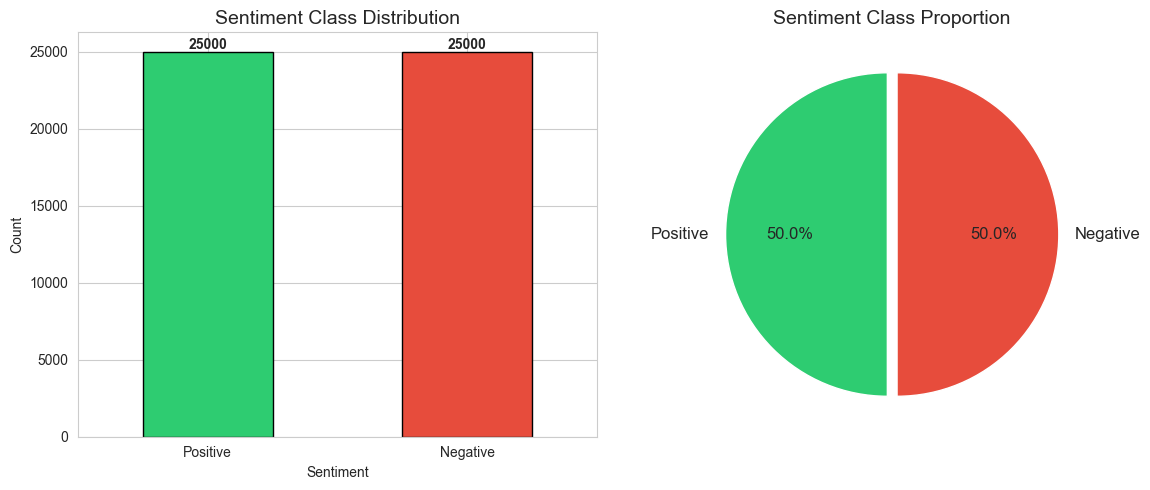

Positive: 25,000 (50.0%)
Negative: 25,000 (50.0%)

The dataset is perfectly balanced -- no resampling needed.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Sentiment Class Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive', 'Negative'], rotation=0)

# Add count labels on bars
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=['Positive', 'Negative'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.03, 0.03), textprops={'fontsize': 12})
axes[1].set_title('Sentiment Class Proportion', fontsize=14)

plt.tight_layout()
plt.show()

print(f'Positive: {sentiment_counts["positive"]:,} ({sentiment_counts["positive"]/len(df)*100:.1f}%)')
print(f'Negative: {sentiment_counts["negative"]:,} ({sentiment_counts["negative"]/len(df)*100:.1f}%)')
print(f'\nThe dataset is perfectly balanced -- no resampling needed.')

## 3. Review Length Analysis

In [5]:
# Compute length features
df['char_count'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

print('Character count statistics:')
print(df.groupby('sentiment')['char_count'].describe().round(1))
print(f'\nWord count statistics:')
print(df.groupby('sentiment')['word_count'].describe().round(1))

Character count statistics:
             count    mean     std   min    25%    50%     75%      max
sentiment                                                              
negative   25000.0  1294.1   945.9  32.0  706.0  973.0  1567.2   8969.0
positive   25000.0  1324.8  1031.5  65.0  691.0  968.0  1614.0  13704.0

Word count statistics:
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


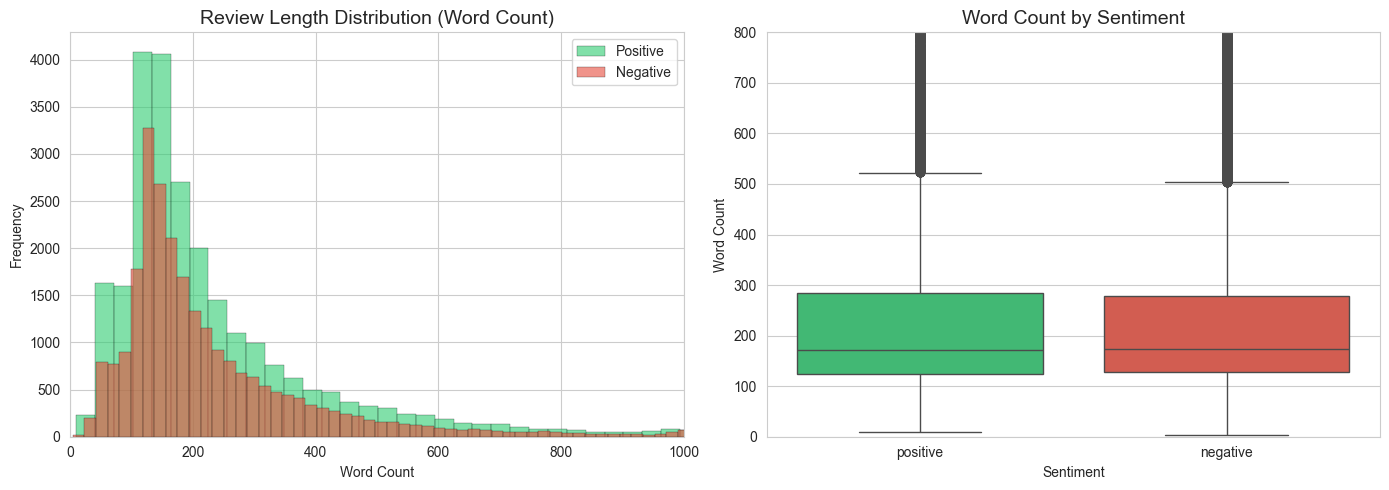

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution by sentiment
for sentiment, color in zip(['positive', 'negative'], colors):
    subset = df[df['sentiment'] == sentiment]
    axes[0].hist(subset['word_count'], bins=80, alpha=0.6, color=color,
                 label=sentiment.capitalize(), edgecolor='black', linewidth=0.3)

axes[0].set_title('Review Length Distribution (Word Count)', fontsize=14)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Box plot comparison
sns.boxplot(data=df, x='sentiment', y='word_count', palette=colors, ax=axes[1])
axes[1].set_title('Word Count by Sentiment', fontsize=14)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
axes[1].set_ylim(0, 800)

plt.tight_layout()
plt.show()

## 4. Text Quality & Noise Analysis

Check for HTML tags, special characters, and other noise that will need preprocessing.

In [7]:
# Check for common noise patterns
html_br = df['review'].str.contains(r'<br\s*/?>', regex=True).sum()
html_tags = df['review'].str.contains(r'<[^>]+>', regex=True).sum()
urls = df['review'].str.contains(r'http[s]?://\S+', regex=True).sum()
special_chars = df['review'].str.contains(r'[&@#$%]', regex=True).sum()

noise_data = {
    'Pattern': ['<br /> tags', 'Any HTML tags', 'URLs', 'Special chars (&@#$%)'],
    'Count': [html_br, html_tags, urls, special_chars],
    'Percentage': [f'{x/len(df)*100:.1f}%' for x in [html_br, html_tags, urls, special_chars]]
}
pd.DataFrame(noise_data)

,Pattern,Count,Percentage
0,<br /> tags,29200,58.4%
1,Any HTML tags,29202,58.4%
2,URLs,119,0.2%
3,Special chars (&@#$%),4728,9.5%


In [8]:
# Show examples of noisy text
print('Example review with HTML tags:')
print('-' * 60)
sample = df[df['review'].str.contains('<br')].iloc[0]['review'][:300]
print(sample)
print('...')

Example review with HTML tags:
------------------------------------------------------------
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru
...


## 5. Word Frequency Analysis

In [9]:
def clean_text_basic(text):
    """Minimal cleaning for frequency analysis."""
    text = re.sub(r'<[^>]+>', ' ', text)  # Remove HTML tags
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Keep only letters and spaces
    return text

# Common English stopwords (small set to avoid nltk dependency in EDA)
STOPWORDS = {'the', 'a', 'an', 'is', 'it', 'in', 'to', 'of', 'and', 'that',
             'this', 'was', 'for', 'with', 'as', 'on', 'are', 'be', 'at',
             'by', 'from', 'or', 'but', 'not', 'have', 'has', 'had', 'i',
             'you', 'he', 'she', 'we', 'they', 'my', 'his', 'her', 'its',
             'our', 'their', 'me', 'him', 'us', 'them', 'who', 'which',
             'what', 'there', 'so', 'if', 'about', 'been', 'would', 'will',
             'can', 'do', 'did', 'just', 'than', 'very', 'all', 'no',
             'one', 'more', 'some', 'could', 'into', 'other', 'were',
             'when', 'how', 'out', 'up', 'also', 'only', 'then', 'after',
             'because', 'make', 'made', 'like', 'even', 'get', 'over'}

def get_word_freq(texts, top_n=30):
    """Get top N word frequencies from a series of texts."""
    all_words = []
    for text in texts:
        cleaned = clean_text_basic(text)
        words = [w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)

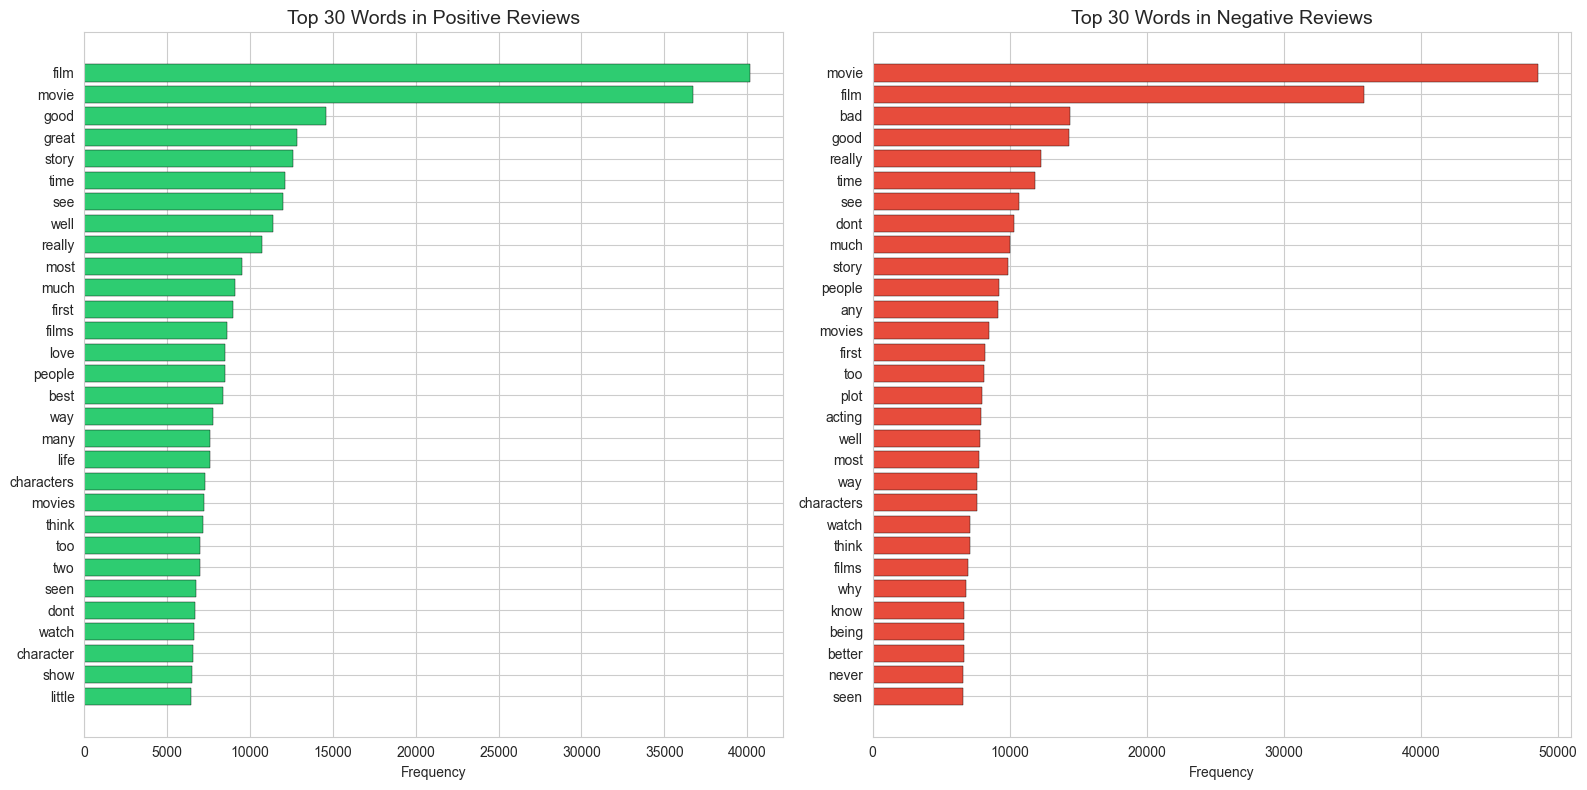

In [10]:
pos_freq = get_word_freq(df[df['sentiment'] == 'positive']['review'])
neg_freq = get_word_freq(df[df['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Positive top words
words, counts = zip(*pos_freq)
axes[0].barh(range(len(words)), counts, color='#2ecc71', edgecolor='black', linewidth=0.3)
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_title('Top 30 Words in Positive Reviews', fontsize=14)
axes[0].set_xlabel('Frequency')

# Negative top words
words, counts = zip(*neg_freq)
axes[1].barh(range(len(words)), counts, color='#e74c3c', edgecolor='black', linewidth=0.3)
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_title('Top 30 Words in Negative Reviews', fontsize=14)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Word Clouds

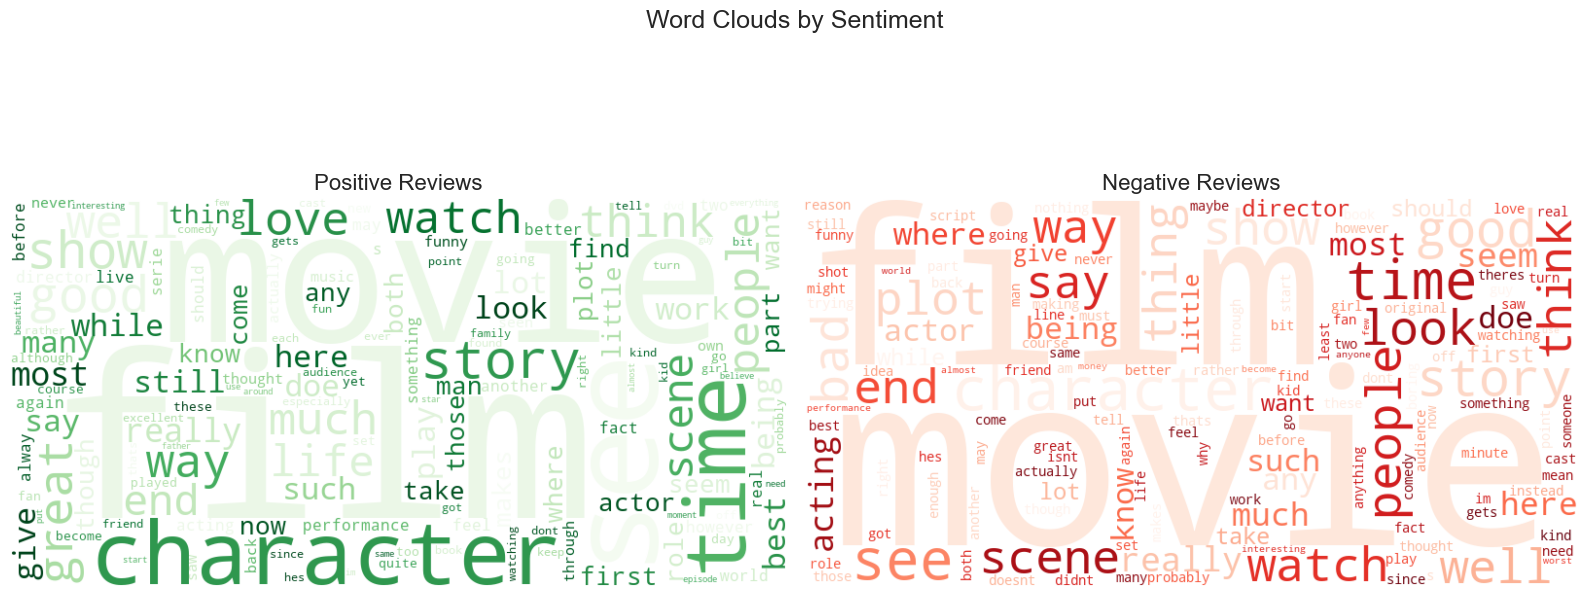

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (sentiment, color, cmap) in enumerate([
    ('positive', '#2ecc71', 'Greens'),
    ('negative', '#e74c3c', 'Reds')
]):
    text = ' '.join(df[df['sentiment'] == sentiment]['review'].apply(clean_text_basic))
    wc = WordCloud(width=800, height=400, max_words=150,
                   stopwords=STOPWORDS, colormap=cmap,
                   background_color='white', random_state=42).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{sentiment.capitalize()} Reviews', fontsize=16)
    axes[idx].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 7. Bigram Analysis

Look at common two-word phrases per sentiment to identify more specific patterns.

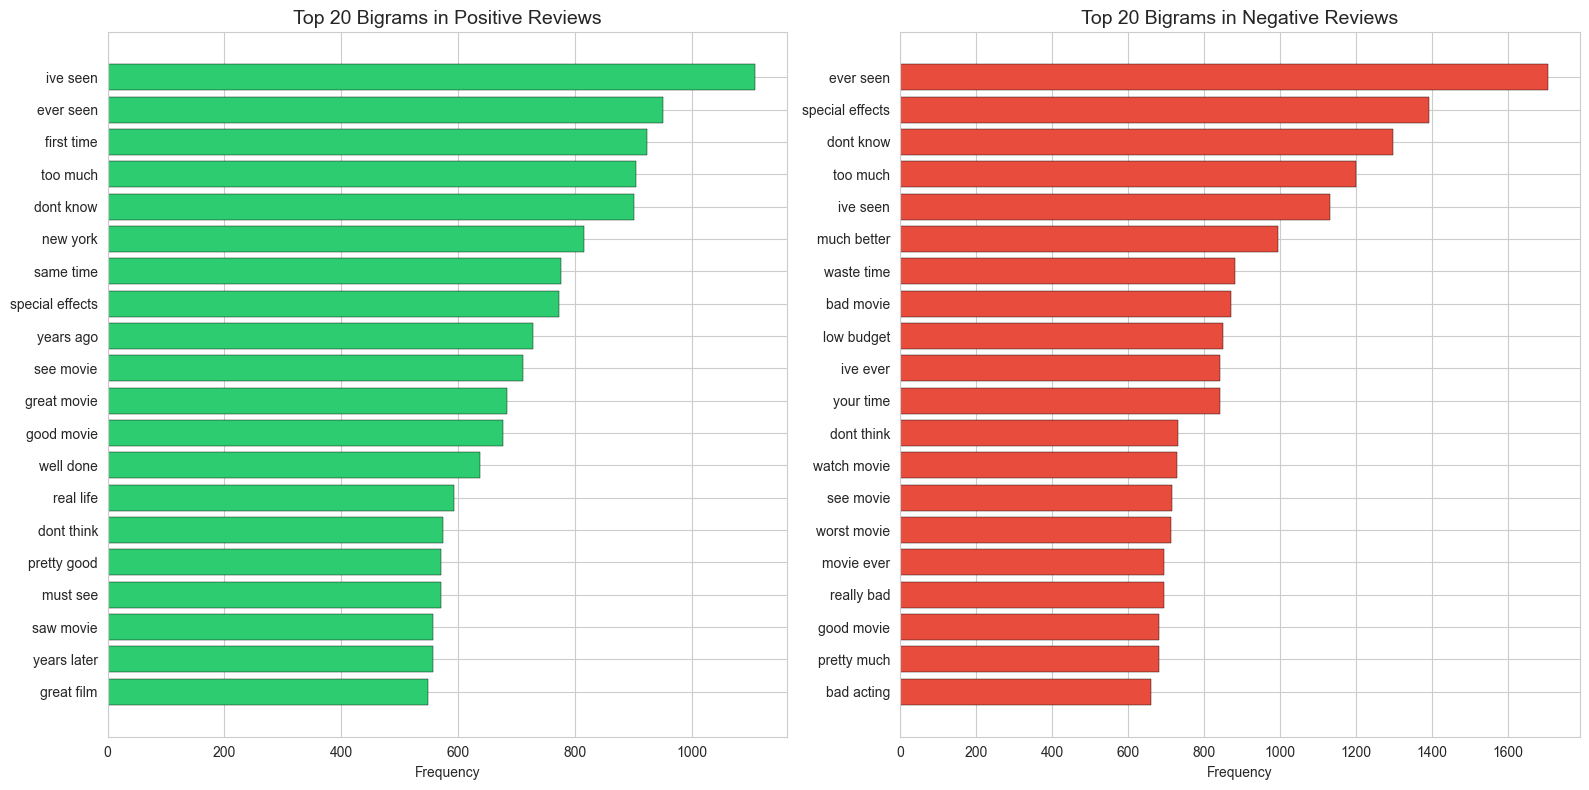

In [12]:
def get_bigram_freq(texts, top_n=20):
    """Get top N bigram frequencies."""
    all_bigrams = []
    for text in texts:
        cleaned = clean_text_basic(text)
        words = [w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2]
        bigrams = [f'{words[i]} {words[i+1]}' for i in range(len(words)-1)]
        all_bigrams.extend(bigrams)
    return Counter(all_bigrams).most_common(top_n)

pos_bigrams = get_bigram_freq(df[df['sentiment'] == 'positive']['review'])
neg_bigrams = get_bigram_freq(df[df['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (bigrams, color, title) in enumerate([
    (pos_bigrams, '#2ecc71', 'Top 20 Bigrams in Positive Reviews'),
    (neg_bigrams, '#e74c3c', 'Top 20 Bigrams in Negative Reviews')
]):
    phrases, counts = zip(*bigrams)
    axes[idx].barh(range(len(phrases)), counts, color=color, edgecolor='black', linewidth=0.3)
    axes[idx].set_yticks(range(len(phrases)))
    axes[idx].set_yticklabels(phrases)
    axes[idx].invert_yaxis()
    axes[idx].set_title(title, fontsize=14)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 8. Preprocessing Observations & Recommendations

Based on this EDA, the following preprocessing steps are needed for model development:

### Data Quality
- **No missing values** -- all 50,000 rows are complete
- **Perfectly balanced** -- 25,000 positive, 25,000 negative (no resampling needed)
- **No duplicates** to remove

### Text Cleaning Required
1. **HTML tag removal** -- ~58% of reviews contain `<br />` tags and other HTML markup
2. **Lowercasing** -- standardize case for consistent tokenization
3. **Punctuation handling** -- remove or normalize punctuation
4. **Stopword removal** -- optional, depends on model (skip for transformers, apply for TF-IDF models)

### Key Observations for Modeling
- Average review is ~231 words -- substantial text for classification
- Positive and negative reviews have similar length distributions
- Clear discriminative words exist per class (e.g., "great", "best" vs. "bad", "worst")
- Bigrams reveal strong sentiment phrases that TF-IDF with bigrams should capture well
- Some reviews are very long (1000+ words) -- may need truncation for transformer models

In [13]:
# Drop helper columns before saving
df.drop(columns=['char_count', 'word_count'], inplace=True)
print('EDA complete. Ready for Phase 2: Model Development.')

EDA complete. Ready for Phase 2: Model Development.
